In [1]:
import numpy as np
import polars as pl
from acquirium import Acquirium
from acquirium.facetgraph import Profile

In [2]:
acq = Acquirium(server_url="localhost", server_port=8000, use_ssl=False)

# A profile keeps facets readable: show the water/223 predicates, hide the
# low-level connection plumbing, and name the paths we traverse a lot.
water = Profile.base().with_(
    allow=["s223:", "nawi:", "qudt:hasQuantityKind", "qudt:hasUnit", "s223:hasRole"],
    deny=["s223:cnx", "s223:connected", "s223:connectedThrough", "s223:connectsAt",
          "s223:connectsThrough", "s223:connectsTo", "s223:connectsFrom", "s223:connectedFrom"],
    edges={
        "measures": "s223:hasProperty",
        "quantity": "s223:hasProperty/qudt:hasQuantityKind",
        "value": "s223:hasValue",
    },
)
g = acq.graph(profile=water)
print("graph version:", acq.graph_version())

graph version: 2


## Explore the UF system

Start from the class and let `facets()` show what's reachable

In [3]:
uf = g.instances("Ultrafiltration unit")
print("UF modules:", uf.count())
uf.frame()

2026-07-03 22:54:58,503 INFO acquirium.facetgraph.resolve graframe: resolved 'Ultrafiltration unit' (class) -> urn:nawi-water-ontology#UltrafiltrationUnit


UF modules: 3


focus
str
"""ph:UF2"""
"""ph:UF3"""
"""ph:UF1"""


In [4]:
# What hangs off a UF module?
uf.facets().show()

                Facets (by=predicate)                
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir ┃ predicate                 ┃ support ┃ edges ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ out │ nawi:hasProcess           │       3 │     3 │
│ out │ s223:hasConnectionPoint   │       3 │     6 │
│ out │ s223:contains             │       3 │     3 │
│ in  │ ^s223:isConnectionPointOf │       3 │     6 │
│ in  │ ^s223:hasMember           │       3 │     3 │
└─────┴───────────────────────────┴─────────┴───────┘

<Facets by=predicate rows=5>

In [5]:
# What hangs off a UF module?
uf.facets(by="pred-obj-type").show()

                             Facets (by=pred-obj-type)                              
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir ┃ predicate                 ┃ object type                  ┃ support ┃ edges ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ out │ s223:contains             │ nawi:UltrafiltrationMembrane │       3 │     3 │
│ out │ nawi:hasProcess           │ nawi:Process-Ultrafiltration │       3 │     3 │
│ out │ s223:hasConnectionPoint   │ s223:OutletConnectionPoint   │       3 │     3 │
│ out │ s223:hasConnectionPoint   │ s223:InletConnectionPoint    │       3 │     3 │
│ in  │ ^s223:isConnectionPointOf │ s223:OutletConnectionPoint   │       3 │     3 │
│ in  │ ^s223:isConnectionPointOf │ s223:InletConnectionPoint    │       3 │     3 │
│ in  │ ^s223:hasMember           │ s223:System                  │       3 │     3 │
└─────┴───────────────────────────┴──────────────────────────────┴─────────┴───────┘

<Facets by=pred-obj-type rows=7>

In [6]:
# i want to know if we have any feed or permeate pressures we can use

# all numeric sensor properties in the graph
props = g.instances("s223:QuantifiableObservableProperty")

# all the presure nodes
pressures = props.having("quantity kind", value="Pressure")
pressures.nodes()

2026-07-03 22:54:59,417 INFO acquirium.facetgraph.resolve graframe: resolved 'quantity kind' (predicate) -> http://qudt.org/schema/qudt/hasQuantityKind
2026-07-03 22:54:59,424 INFO acquirium.facetgraph.resolve graframe: resolved 'Pressure' -> http://qudt.org/vocab/quantitykind/Pressure


['urn:port-hueneme#UF-backwash-pressure',
 'urn:port-hueneme#UF-feed-pressure',
 'urn:port-hueneme#UF-filtrate-header-pressure',
 'urn:port-hueneme#UF1-filtrate-pressure',
 'urn:port-hueneme#UF2-filtrate-pressure',
 'urn:port-hueneme#UF3-filtrate-pressure']

In [7]:
# '^has property' is the *inverse*, so this returns what the pressure is *of*, and asks for the role of that
feed_pressure = pressures.having("^has property/has role", value="feed")
feed_pressure.nodes()

2026-07-03 22:54:59,456 INFO acquirium.facetgraph.resolve graframe: resolved 'has property' (predicate) -> http://data.ashrae.org/standard223#hasProperty
2026-07-03 22:54:59,461 INFO acquirium.facetgraph.resolve graframe: resolved 'has role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:54:59,463 INFO acquirium.facetgraph.resolve graframe: resolved 'feed' -> urn:nawi-water-ontology#Role-Feed


['urn:port-hueneme#UF-feed-pressure']

In [8]:
# similar thing for permate pressure
permeate_pressure = pressures.having("^has property/has role", value="permeate")
permeate_pressure.nodes()

2026-07-03 22:54:59,488 INFO acquirium.facetgraph.resolve graframe: resolved 'has property' (predicate) -> http://data.ashrae.org/standard223#hasProperty
2026-07-03 22:54:59,493 INFO acquirium.facetgraph.resolve graframe: resolved 'has role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:54:59,495 INFO acquirium.facetgraph.resolve graframe: resolved 'permeate' -> urn:nawi-water-ontology#Role-Permeate


['urn:port-hueneme#UF1-filtrate-pressure',
 'urn:port-hueneme#UF2-filtrate-pressure',
 'urn:port-hueneme#UF3-filtrate-pressure']

# Assembling Data

In [9]:
# the plant only has one 'feed'. We want the pressure, temperature, and turbidity of the feed
pressure = props.having("qudt:hasQuantityKind", value="Pressure") \
                 .having("^s223:hasProperty/s223:hasRole", value="Feed")
temperature = props.having("qudt:hasQuantityKind", value="Temperature") \
                   .having("^s223:hasProperty/s223:hasRole", value="Feed")
turbidity = props.having("qudt:hasQuantityKind", value="Turbidity") \
                 .having("^s223:hasProperty/s223:hasRole", value="Feed")

# Every property also carries its unit as qudt:hasUnit -- that's just one more facet hop.
# So we never hardcode "PSI": we ask the graph. (one property -> one unit, so we unwrap it.)
def unit_of(sel):
    """The QUDT unit URI annotated on the property/-ies in `sel` (via qudt:hasUnit)."""
    units = set(sel.follow("has unit").nodes())
    assert len(units) == 1, f"expected a single unit, found {units}"
    return units.pop()

print("feed pressure unit   :", unit_of(pressure))
print("feed temperature unit:", unit_of(temperature))

2026-07-03 22:54:59,529 INFO acquirium.facetgraph.resolve graframe: resolved 'Pressure' -> http://qudt.org/vocab/quantitykind/Pressure
2026-07-03 22:54:59,538 INFO acquirium.facetgraph.resolve graframe: resolved 'Feed' -> urn:nawi-water-ontology#Role-Feed
2026-07-03 22:54:59,545 INFO acquirium.facetgraph.resolve graframe: resolved 'Temperature' -> http://qudt.org/vocab/quantitykind/Temperature
2026-07-03 22:54:59,550 INFO acquirium.facetgraph.resolve graframe: resolved 'Feed' -> urn:nawi-water-ontology#Role-Feed
2026-07-03 22:54:59,560 INFO acquirium.facetgraph.resolve graframe: resolved 'Turbidity' -> http://qudt.org/vocab/quantitykind/Turbidity
2026-07-03 22:54:59,565 INFO acquirium.facetgraph.resolve graframe: resolved 'Feed' -> urn:nawi-water-ontology#Role-Feed
2026-07-03 22:54:59,569 INFO acquirium.facetgraph.resolve graframe: resolved 'has unit' (predicate) -> http://qudt.org/schema/qudt/hasUnit
2026-07-03 22:54:59,595 INFO acquirium.facetgraph.resolve graframe: resolved 'has uni

feed pressure unit   : http://qudt.org/vocab/unit/PSI
feed temperature unit: http://qudt.org/vocab/unit/DEG_C


In [10]:
# for each of the filtration units, we want: permeate flow rate and pressure
# Our earlier variable 'uf' has all the filtration unit.s Let's figure out how to get the flow rate + pressure on them
# Always good to start with the facets!
uf.facets(by="pred-obj-type").show()

                             Facets (by=pred-obj-type)                              
┏━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir ┃ predicate                 ┃ object type                  ┃ support ┃ edges ┃
┡━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ out │ s223:contains             │ nawi:UltrafiltrationMembrane │       3 │     3 │
│ out │ nawi:hasProcess           │ nawi:Process-Ultrafiltration │       3 │     3 │
│ out │ s223:hasConnectionPoint   │ s223:OutletConnectionPoint   │       3 │     3 │
│ out │ s223:hasConnectionPoint   │ s223:InletConnectionPoint    │       3 │     3 │
│ in  │ ^s223:isConnectionPointOf │ s223:OutletConnectionPoint   │       3 │     3 │
│ in  │ ^s223:isConnectionPointOf │ s223:InletConnectionPoint    │       3 │     3 │
│ in  │ ^s223:hasMember           │ s223:System                  │       3 │     3 │
└─────┴───────────────────────────┴──────────────────────────────┴─────────┴───────┘

<Facets by=pred-obj-type rows=7>

In [11]:
# look at what is measured directly on the filtration units. I use 'pred-obj' so I get the specific values of the quantity kind/etc
uf.follow("contains").facets(by="pred-obj").show()
# looks like we can get the area of the unit's membrane!

2026-07-03 22:54:59,779 INFO acquirium.facetgraph.resolve graframe: resolved 'contains' (predicate) -> http://data.ashrae.org/standard223#contains


                          Facets (by=pred-obj)                           
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir       ┃ predicate        ┃ object               ┃ support ┃ edges ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ ↳ virtual │ quantity         │ qk:Area              │       3 │     3 │
│ ↳ virtual │ measures         │ ph:UF3-membrane-area │       1 │     1 │
│ ↳ virtual │ measures         │ ph:UF1-membrane-area │       1 │     1 │
│ ↳ virtual │ measures         │ ph:UF2-membrane-area │       1 │     1 │
│ out       │ s223:hasProperty │ ph:UF2-membrane-area │       1 │     1 │
│ out       │ s223:hasProperty │ ph:UF3-membrane-area │       1 │     1 │
│ out       │ s223:hasProperty │ ph:UF1-membrane-area │       1 │     1 │
│ in        │ ^s223:contains   │ ph:UF2               │       1 │     1 │
│ in        │ ^s223:contains   │ ph:UF3               │       1 │     1 │
│ in        │ ^s223:contains   │ ph:UF1               │       1 │     1 │
└───────────┴──────────────────┴──────────────────────┴─────────┴───────┘

<Facets by=pred-obj rows=10>

In [12]:
# some usage of 'mark' to indicate what parts of the query we want to save; use this to extract the areas of 
areas = uf.mark("filter").follow("contains").follow("measures").mark("prop") \
   .follow("s223:hasValue").mark("area") \
   .to("prop").follow("has unit").mark("unit") \
   .select("filter", "area", "unit")
areas

2026-07-03 22:54:59,904 INFO acquirium.facetgraph.resolve graframe: resolved 'contains' (predicate) -> http://data.ashrae.org/standard223#contains
2026-07-03 22:54:59,906 INFO acquirium.facetgraph.resolve graframe: resolved 'has unit' (predicate) -> http://qudt.org/schema/qudt/hasUnit


filter,area,unit
str,f64,str
"""ph:UF2""",50.0,"""unit:M2"""
"""ph:UF3""",50.0,"""unit:M2"""
"""ph:UF1""",50.0,"""unit:M2"""


In [13]:
# looking on the 'outlet' of the ultrafiltration unit for the properties of the permeate
uf.follow("has connection point", is_a="outlet connection point").facets(by="pred-obj-type").show()

2026-07-03 22:54:59,935 INFO acquirium.facetgraph.resolve graframe: resolved 'has connection point' (predicate) -> http://data.ashrae.org/standard223#hasConnectionPoint
2026-07-03 22:54:59,937 INFO acquirium.facetgraph.resolve graframe: resolved 'outlet connection point' (class) -> http://data.ashrae.org/standard223#OutletConnectionPoint


                                   Facets (by=pred-obj-type)                                    
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir       ┃ predicate                ┃ object type                         ┃ support ┃ edges ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ ↳ virtual │ measures                 │ s223:QuantifiableObservableProperty │       3 │     6 │
│ ↳ virtual │ measures                 │ ns2:VirtualPoint                    │       3 │     6 │
│ out       │ s223:isConnectionPointOf │ nawi:UltrafiltrationUnit            │       3 │     3 │
│ out       │ s223:hasRole             │ s223:EnumerationKind-Role           │       3 │     3 │
│ out       │ s223:hasProperty         │ s223:QuantifiableObservableProperty │       3 │     6 │
│ out       │ s223:hasProperty         │ ns2:VirtualPoint                    │       3 │     6 │
│ out       │ s223:hasRole             │ nawi:Role-Permeate                  │       3 │     3 │
│ out       │ s223:hasMedium           │ s223:Fluid-Water                    │       3 │     3 │
│ in        │ ^s223:hasConnectionPoint │ nawi:UltrafiltrationUnit            │       3 │     3 │
└───────────┴──────────────────────────┴─────────────────────────────────────┴─────────┴───────┘

<Facets by=pred-obj-type rows=9>

In [14]:
uf.follow("has connection point", is_a="outlet connection point").having("role", value='permeate').facets(by="pred-obj-type").show()

2026-07-03 22:55:00,080 INFO acquirium.facetgraph.resolve graframe: resolved 'has connection point' (predicate) -> http://data.ashrae.org/standard223#hasConnectionPoint
2026-07-03 22:55:00,082 INFO acquirium.facetgraph.resolve graframe: resolved 'outlet connection point' (class) -> http://data.ashrae.org/standard223#OutletConnectionPoint
2026-07-03 22:55:00,088 INFO acquirium.facetgraph.resolve graframe: resolved 'role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:55:00,093 INFO acquirium.facetgraph.resolve graframe: resolved 'permeate' -> urn:nawi-water-ontology#Role-Permeate


                                   Facets (by=pred-obj-type)                                    
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ dir       ┃ predicate                ┃ object type                         ┃ support ┃ edges ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ ↳ virtual │ measures                 │ s223:QuantifiableObservableProperty │       3 │     6 │
│ ↳ virtual │ measures                 │ ns2:VirtualPoint                    │       3 │     6 │
│ out       │ s223:isConnectionPointOf │ nawi:UltrafiltrationUnit            │       3 │     3 │
│ out       │ s223:hasRole             │ s223:EnumerationKind-Role           │       3 │     3 │
│ out       │ s223:hasProperty         │ s223:QuantifiableObservableProperty │       3 │     6 │
│ out       │ s223:hasProperty         │ ns2:VirtualPoint                    │       3 │     6 │
│ out       │ s223:hasRole             │ nawi:Role-Permeate                  │       3 │     3 │
│ out       │ s223:hasMedium           │ s223:Fluid-Water                    │       3 │     3 │
│ in        │ ^s223:hasConnectionPoint │ nawi:UltrafiltrationUnit            │       3 │     3 │
└───────────┴──────────────────────────┴─────────────────────────────────────┴─────────┴───────┘

<Facets by=pred-obj-type rows=9>

In [15]:
# get properties of the filter permeate
filter_perm_props = uf.follow("has connection point", is_a="outlet connection point").having("role", value='permeate').follow("hasProperty")
# properties with flow rate
perm_gpm = filter_perm_props.having("has quantity kind", value="flow rate")
perm_gpm.nodes()

2026-07-03 22:55:00,239 INFO acquirium.facetgraph.resolve graframe: resolved 'has connection point' (predicate) -> http://data.ashrae.org/standard223#hasConnectionPoint
2026-07-03 22:55:00,241 INFO acquirium.facetgraph.resolve graframe: resolved 'outlet connection point' (class) -> http://data.ashrae.org/standard223#OutletConnectionPoint
2026-07-03 22:55:00,249 INFO acquirium.facetgraph.resolve graframe: resolved 'role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:55:00,254 INFO acquirium.facetgraph.resolve graframe: resolved 'permeate' -> urn:nawi-water-ontology#Role-Permeate
2026-07-03 22:55:00,263 INFO acquirium.facetgraph.resolve graframe: resolved 'hasProperty' (predicate) -> http://data.ashrae.org/standard223#hasProperty
2026-07-03 22:55:00,267 INFO acquirium.facetgraph.resolve graframe: resolved 'has quantity kind' (predicate) -> http://qudt.org/schema/qudt/hasQuantityKind
2026-07-03 22:55:00,300 INFO acquirium.facetgraph.resolve graframe: resolved 'fl

['urn:port-hueneme#UF1-filtrate-flow',
 'urn:port-hueneme#UF2-filtrate-flow',
 'urn:port-hueneme#UF3-filtrate-flow']

In [16]:
perm_psi = filter_perm_props.having("has quantity kind", value="pressure")
# properties with pressure
perm_psi.nodes()

2026-07-03 22:55:00,330 INFO acquirium.facetgraph.resolve graframe: resolved 'has quantity kind' (predicate) -> http://qudt.org/schema/qudt/hasQuantityKind
2026-07-03 22:55:00,335 INFO acquirium.facetgraph.resolve graframe: resolved 'pressure' -> http://qudt.org/vocab/quantitykind/Pressure


['urn:port-hueneme#UF1-filtrate-pressure',
 'urn:port-hueneme#UF2-filtrate-pressure',
 'urn:port-hueneme#UF3-filtrate-pressure']

In [17]:
perm_psi.dataframe()

time,ph:UF2-filtrate-pressure,ph:UF1-filtrate-pressure,ph:UF3-filtrate-pressure
"datetime[μs, UTC]",f64,f64,f64
2012-06-21 11:21:19.072310 UTC,5.084328,5.675665,5.486742
2012-06-21 11:21:20.072390 UTC,4.905358,5.548452,5.512351
2012-06-21 11:21:21.072470 UTC,4.734747,5.382001,5.479921
2012-06-21 11:21:22.072464 UTC,4.611586,5.218013,5.446025
2012-06-21 11:21:23.071507 UTC,4.837591,5.40685,5.463121
…,…,…,…
2015-04-02 14:30:18.191117 UTC,0.491648,0.467604,0.650859
2015-04-02 14:30:18.940637 UTC,0.482286,0.460724,0.645904
2015-04-02 14:30:19.440892 UTC,0.484363,0.458297,0.654086


## Assemble the aligned timeseries

We don't fetch each signal and stitch them together by hand — the query layer does that. `assemble_unit(mod)`
gathers a module's signals (plant-wide feed conditions, pump speed and backwash flow, plus this module's
permeate flow and pressure) into **one selection** and calls `.dataframe()` **once**; acquirium fetches every
series and joins them on `time` server-side. We loop it over every UF module → `unit_frames`, keyed by module
label. Narrow the window first — the raw record is 1 Hz over years.

In [18]:
# Shared across modules (plant-wide signals) + the analysis window.
pump = props.having("qudt:hasQuantityKind", value="qk:AngularVelocity")  # qk: prefix -> clean resolve
bw = (props.having("qudt:hasQuantityKind", value="flow rate")
           .having("^s223:hasProperty/nawi:hasProcess", value="nawi:Process-Backwashing"))
START = "2013-06-05T00:00:00Z"   # one continuously-operating day; widen for more cycles,
END   = "2013-06-06T00:00:00Z"   # or set both to None to pull everything (large — 1 Hz over years)
modules = sorted(g.instances("nawi:UltrafiltrationUnit").nodes())

def permeate(mod, quantity):
    """A module's permeate-side property for a given quantity kind (its outlet CP)."""
    return (mod.follow("has connection point", is_a="outlet connection point")
               .having("role", value="permeate")
               .follow("hasProperty").having("has quantity kind", value=quantity))

def assemble_unit(mod):
    """Fetch one UF module's fouling signals as a single wide, time-aligned frame."""
    # Friendly name -> the facet selection that identifies that point. Feed conditions, pump speed and
    # backwash flow are plant-wide; the permeate flow + pressure are this module's (3 parallel modules).
    signals = {
        "feed_p_psi": pressure,
        "temp_c":     temperature,
        "perm_gpm":   permeate(mod, "flow rate"),
        "filt_p_psi": permeate(mod, "pressure"),
        "pump_rpm":   pump,
        "bw_gpm":     bw,
    }
    # Hand ALL those points to ONE selection and pull once: the data layer fetches every series
    # and joins them on `time` for us -> a single wide frame, no manual per-signal join loop.
    point_names = {sel.nodes()[0]: name for name, sel in signals.items()}
    wide = g.nodes(*point_names).dataframe(shape="wide", start=START, end=END)
    # columns come back keyed by point URI; rename them to our friendly names.
    return wide.rename({acq.client.compact_uri(uri): name for uri, name in point_names.items()})

# Apply it to every UF module the graph knows about -> {label: wide frame}
unit_frames = {m.rsplit("#", 1)[-1]: assemble_unit(g.nodes(m)) for m in modules}
for label, d in unit_frames.items():
    print(f"{label}: {d.shape}")
unit_frames[next(iter(unit_frames))].head()

2026-07-03 22:55:09,046 INFO acquirium.facetgraph.resolve graframe: resolved 'flow rate' -> http://qudt.org/vocab/quantitykind/VolumeFlowRate
2026-07-03 22:55:09,071 INFO acquirium.facetgraph.resolve graframe: resolved 'has connection point' (predicate) -> http://data.ashrae.org/standard223#hasConnectionPoint
2026-07-03 22:55:09,073 INFO acquirium.facetgraph.resolve graframe: resolved 'outlet connection point' (class) -> http://data.ashrae.org/standard223#OutletConnectionPoint
2026-07-03 22:55:09,079 INFO acquirium.facetgraph.resolve graframe: resolved 'role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:55:09,084 INFO acquirium.facetgraph.resolve graframe: resolved 'permeate' -> urn:nawi-water-ontology#Role-Permeate
2026-07-03 22:55:09,091 INFO acquirium.facetgraph.resolve graframe: resolved 'hasProperty' (predicate) -> http://data.ashrae.org/standard223#hasProperty
2026-07-03 22:55:09,095 INFO acquirium.facetgraph.resolve graframe: resolved 'has quantity kin

UF1: (86327, 7)
UF2: (86327, 7)
UF3: (86327, 7)


time,temp_c,perm_gpm,pump_rpm,bw_gpm,filt_p_psi,feed_p_psi
"datetime[μs, UTC]",f64,f64,f64,f64,f64,f64
2013-06-05 00:00:00.026352 UTC,17.84411,9.546284,0.942875,0.007666,32.061424,35.318356
2013-06-05 00:00:01.026345 UTC,17.842951,9.557243,0.942454,0.005638,32.309389,35.031876
2013-06-05 00:00:02.026425 UTC,17.837573,9.548231,0.944733,0.006096,32.331234,35.187559
2013-06-05 00:00:03.025469 UTC,17.831691,9.515783,0.891054,0.007448,32.372498,35.676087
2013-06-05 00:00:04.025549 UTC,17.820278,9.603463,0.913436,0.004309,32.161798,35.153109


## Step 1 — normalized permeability

Fouling shows up as *permeability decline*, so we want **temperature-normalized specific flux**:

$$\text{norm perm} \;=\; \frac{J}{\text{TMP}}\,e^{-0.0239\,(T-20)}, \qquad J=\frac{Q_\text{perm}}{A},\quad \text{TMP}=P_\text{feed}-P_\text{filtrate}$$

Same pattern as the assembly step: write **`normalize(df)`** once and map it over `unit_frames`, so
every module gets the same treatment. The signals arrive in the plant's native units, but the math
wants bar and LMH — rather than hardcode constants like `0.0689476`, or even assume "the pressure is
in PSI", we let the **graph and acquirium** handle units. Every property is annotated with its
`qudt:hasUnit`, so `unit_of(...)` reads the *source* unit straight off the metadata graph, and
`acq.client.get_conversion_factors(...)` returns the exact linear rule from the QUDT ontology. We
only ever name the **target** we want the math in.

In [19]:
# No magic numbers *and* no hardcoded source units. `convert_units` asks the server for the
# linear rule between two compatible QUDT units; the *from* unit is whatever the graph says
# each property is in (`unit_of(...)`, via qudt:hasUnit). We only name the *target* (bar, L/h).
def convert_units(col, frm, to):
    """polars expression: `col` (in QUDT unit `frm`) expressed in unit `to`."""
    f = acq.client.get_conversion_factors(frm, to)
    assert f["compatible"], f"{frm} -> {to} are not dimensionally compatible"
    # QUDT linear form:  SI = (v + from_offset) * from_mult ;  out = SI / to_mult - to_offset
    return (col + f["from_offset"]) * f["from_multiplier"] / f["to_multiplier"] - f["to_offset"]

# Source units read from the graph once — they're identical across modules (all PSI / gal-min).
m0 = g.nodes(modules[0])
u_feed_p = unit_of(pressure)
u_filt_p = unit_of(permeate(m0, "pressure"))
u_perm_q = unit_of(permeate(m0, "flow rate"))

area_m2 = areas["area"][0]   # static design value; all UF modules are 50 m^2

def normalize(df):
    """TMP + temperature-normalized specific flux, keeping only genuine filtration samples."""
    # TMP = feed pressure - filtrate pressure -> bar; specific flux = permeate flow -> L/h, / area -> LMH
    df = df.with_columns([
        (convert_units(pl.col("feed_p_psi"), u_feed_p, "BAR")
         - convert_units(pl.col("filt_p_psi"), u_filt_p, "BAR")).alias("tmp_bar"),
        (convert_units(pl.col("perm_gpm"), u_perm_q, "L-PER-HR") / area_m2).alias("flux_lmh"),
    ])
    # normalize out temperature (viscosity rule, temp_c is DEG_C), then mask to real filtration
    # (pump on, sensible TMP + established forward flux)
    df = df.with_columns([
        (pl.col("flux_lmh") / pl.col("tmp_bar")
         * (-0.0239 * (pl.col("temp_c") - 20.0)).exp()).alias("norm_perm_lmh_bar"),
        ((pl.col("pump_rpm") > 0.1) & (pl.col("tmp_bar") > 0.1) & (pl.col("flux_lmh") > 5.0)).alias("filtering"),
    ])
    return df.filter(pl.col("filtering") & pl.col("norm_perm_lmh_bar").is_finite()).sort("time")

# Map it over every module -> {label: operating-only frame}
ops = {label: normalize(d) for label, d in unit_frames.items()}
for label, op in ops.items():
    print(f"{label}: operating samples {len(op)} / {len(unit_frames[label])}")
ops[next(iter(ops))].select(["time", "temp_c", "tmp_bar", "flux_lmh", "norm_perm_lmh_bar"]).head()

2026-07-03 22:55:10,833 INFO acquirium.facetgraph.resolve graframe: resolved 'has unit' (predicate) -> http://qudt.org/schema/qudt/hasUnit
2026-07-03 22:55:10,856 INFO acquirium.facetgraph.resolve graframe: resolved 'has connection point' (predicate) -> http://data.ashrae.org/standard223#hasConnectionPoint
2026-07-03 22:55:10,858 INFO acquirium.facetgraph.resolve graframe: resolved 'outlet connection point' (class) -> http://data.ashrae.org/standard223#OutletConnectionPoint
2026-07-03 22:55:10,864 INFO acquirium.facetgraph.resolve graframe: resolved 'role' (predicate) -> http://data.ashrae.org/standard223#hasRole
2026-07-03 22:55:10,868 INFO acquirium.facetgraph.resolve graframe: resolved 'permeate' -> urn:nawi-water-ontology#Role-Permeate
2026-07-03 22:55:10,875 INFO acquirium.facetgraph.resolve graframe: resolved 'hasProperty' (predicate) -> http://data.ashrae.org/standard223#hasProperty
2026-07-03 22:55:10,878 INFO acquirium.facetgraph.resolve graframe: resolved 'has quantity kind' 

UF1: operating samples 58118 / 86327
UF2: operating samples 58163 / 86327
UF3: operating samples 56681 / 86327


time,temp_c,tmp_bar,flux_lmh,norm_perm_lmh_bar
"datetime[μs, UTC]",f64,f64,f64,f64
2013-06-05 00:00:00.026352 UTC,17.84411,0.224558,43.363939,203.319227
2013-06-05 00:00:01.026345 UTC,17.842951,0.187709,43.41372,243.518272
2013-06-05 00:00:02.026425 UTC,17.837573,0.196937,43.372784,231.918817
2013-06-05 00:00:03.025469 UTC,17.831691,0.227774,43.22539,199.86655
2013-06-05 00:00:04.025549 UTC,17.820278,0.206244,43.623673,222.826259


## Step 2 — detect cleaning (backwash) events

`bw_gpm` — the shared backwash-flow tag we pulled in during assembly — makes cleaning explicit: a
**backwash onset** ends a filtration cycle. We number cycles by cumulative onset count and tag each
operating sample with its cycle. The three modules are backwashed *sequentially* off that one tag, so
several onsets fire around each real cycle — Step 3 sorts the real cycles from the transition fragments.

In [20]:
BW_ON_GPM = 1.0   # backwash flow above this = backwash active

def assign_cycles(full_df, op):
    """Number filtration cycles by backwash onset, tag each operating sample with its cycle."""
    d = full_df.sort("time").with_columns((pl.col("bw_gpm") > BW_ON_GPM).fill_null(False).alias("bw_on"))
    # a rising edge (off -> on) is a backwash onset; the cumulative onset count is the cycle index
    d = d.with_columns((pl.col("bw_on") & ~pl.col("bw_on").shift(1, fill_value=False)).alias("bw_onset"))
    d = d.with_columns(pl.col("bw_onset").cast(pl.Int32).cum_sum().alias("cycle"))
    tagged = op.join(d.select(["time", "cycle"]), on="time", how="left", coalesce=True).drop_nulls(["cycle"])
    return tagged, int(d["bw_onset"].sum())

# full frame gives the backwash edges; op is the operating-only frame we tag. Re-map over modules.
tagged_ops = {}
for label in unit_frames:
    tagged_ops[label], n_onsets = assign_cycles(unit_frames[label], ops[label])
    print(f"{label}: {n_onsets} backwash onsets -> {tagged_ops[label]['cycle'].n_unique()} raw filtration cycles")
ops = tagged_ops

UF1: 199 backwash onsets -> 151 raw filtration cycles
UF2: 199 backwash onsets -> 152 raw filtration cycles
UF3: 199 backwash onsets -> 148 raw filtration cycles


## Step 3 — per-cycle fouling rate

Within each cycle we fit normalized permeability vs elapsed time; the slope is the fouling rate
(permeability *decline* → negative slope; magnitude per hour). Two guards matter: keep only cycles
`≥ MIN_CYCLE_MIN` (dropping the short backwash-transition fragments the sequential tag creates), and
**trim the first `TRIM_S` seconds** of each cycle while TMP settles. On the reference day this yields
~25 min cycles, matching Gu et al. (20–50 min).

In [21]:
MIN_CYCLE_MIN = 10    # a real filtration cycle is at least this long
TRIM_S        = 60    # skip the first minute of each cycle (pressure settling)

def fouling_rates(op):
    """Linear fit of normalized permeability vs time within each real cycle -> signed slope."""
    rows = []
    for cyc, part in op.group_by("cycle", maintain_order=True):
        part = part.sort("time")
        t0 = part["time"][0]
        secs = part.select(((pl.col("time") - t0).dt.total_seconds()).alias("s"))["s"].to_numpy()
        if secs[-1] < MIN_CYCLE_MIN * 60:       # a backwash-transition fragment, not a cycle
            continue
        keep = secs >= TRIM_S
        if keep.sum() < 60:
            continue
        hrs = secs[keep] / 3600.0
        y = part["norm_perm_lmh_bar"].to_numpy()[keep]
        slope, _ = np.polyfit(hrs, y, 1)        # LMH/bar per hour
        rows.append({
            "cycle": int(cyc[0]) if isinstance(cyc, tuple) else int(cyc),
            "start": t0,
            "duration_min": float(secs[-1] / 60.0),
            "n": int(keep.sum()),
            "fouling_rate": float(slope),        # signed (negative = declining permeability)
            "perm_median": float(np.median(y)),
        })
    return pl.DataFrame(rows).sort("start")

# Map it over each module's tagged operating frame -> {label: per-cycle table}
cycles_by_unit = {label: fouling_rates(op) for label, op in ops.items()}
for label, cy in cycles_by_unit.items():
    print(f"{label}: {len(cy)} real cycles | median duration {cy['duration_min'].median():.1f} min")
cycles_by_unit[next(iter(cycles_by_unit))]

UF1: 34 real cycles | median duration 24.7 min
UF2: 34 real cycles | median duration 25.2 min
UF3: 34 real cycles | median duration 25.2 min


cycle,start,duration_min,n,fouling_rate,perm_median
i64,"datetime[μs, UTC]",f64,i64,f64,f64
8,2013-06-05 00:39:23.026435 UTC,24.666667,1421,-113.206269,234.926239
12,2013-06-05 01:07:06.025555 UTC,25.7,1481,-63.404235,203.737543
20,2013-06-05 02:03:43.025846 UTC,25.8,1489,-63.673343,216.424243
24,2013-06-05 02:32:30.025679 UTC,24.7,1423,-91.274164,239.153003
32,2013-06-05 03:28:58.026461 UTC,24.683333,1422,-123.723058,236.723698
…,…,…,…,…,…
175,2013-06-05 20:52:56.026128 UTC,25.75,1484,-61.349426,210.55277
183,2013-06-05 21:49:20.025724 UTC,25.75,1484,-78.280612,220.097259
187,2013-06-05 22:18:06.026429 UTC,24.65,1420,-92.607706,245.889547


## Step 4 — flag anomalies + trend

For each module, z-score the latest cycle's fouling-rate magnitude against the history of prior cycles;
also watch whether cycles are getting **shorter** (fouling acceleration).

In [22]:
def flag_latest(cycles):
    """z-score the latest cycle's |fouling rate| against the prior-cycle history."""
    cy = cycles.with_columns(pl.col("fouling_rate").abs().alias("rate_mag"))
    mu, sd = cy["rate_mag"][:-1].mean(), cy["rate_mag"][:-1].std()
    cy = cy.with_columns(((pl.col("rate_mag") - mu) / (sd if sd else 1.0)).alias("z"))
    return cy, mu, sd

flagged = {}
for label, cy in cycles_by_unit.items():
    if len(cy) < 3:
        print(f"{label}: too few cycles to flag")
        continue
    cyz, mu, sd = flag_latest(cy)
    flagged[label] = cyz
    z = cyz["z"][-1]
    # cycle-length trend (shrinking = accelerating fouling)
    h = cyz.select(((pl.col("start") - cyz["start"][0]).dt.total_seconds() / 3600).alias("h"))["h"].to_numpy()
    trend = np.polyfit(h, cyz["duration_min"].to_numpy(), 1)[0]
    verdict = "ALARM: accelerated fouling" if abs(z) > 3 else "nominal"
    print(f"{label}: latest cycle z={z:+.2f} -> {verdict}"
          f"  | history mean|rate|={mu:.3g}  | cycle-length trend {trend:+.3f} min/h"
          f" {'(shrinking!)' if trend < 0 else ''}")

UF1: latest cycle z=-1.90 -> nominal  | history mean|rate|=87.4  | cycle-length trend -0.056 min/h (shrinking!)
UF2: latest cycle z=+1.92 -> nominal  | history mean|rate|=2.15  | cycle-length trend -0.056 min/h (shrinking!)
UF3: latest cycle z=-1.06 -> nominal  | history mean|rate|=19.8  | cycle-length trend +0.000 min/h 


## Visualize

Three parallel modules, three independent analyses. Overlay them: temperature-normalized permeability over
time (colored by module) and the per-cycle fouling-rate magnitude (log axis, since the per-module magnitudes span a wide range).

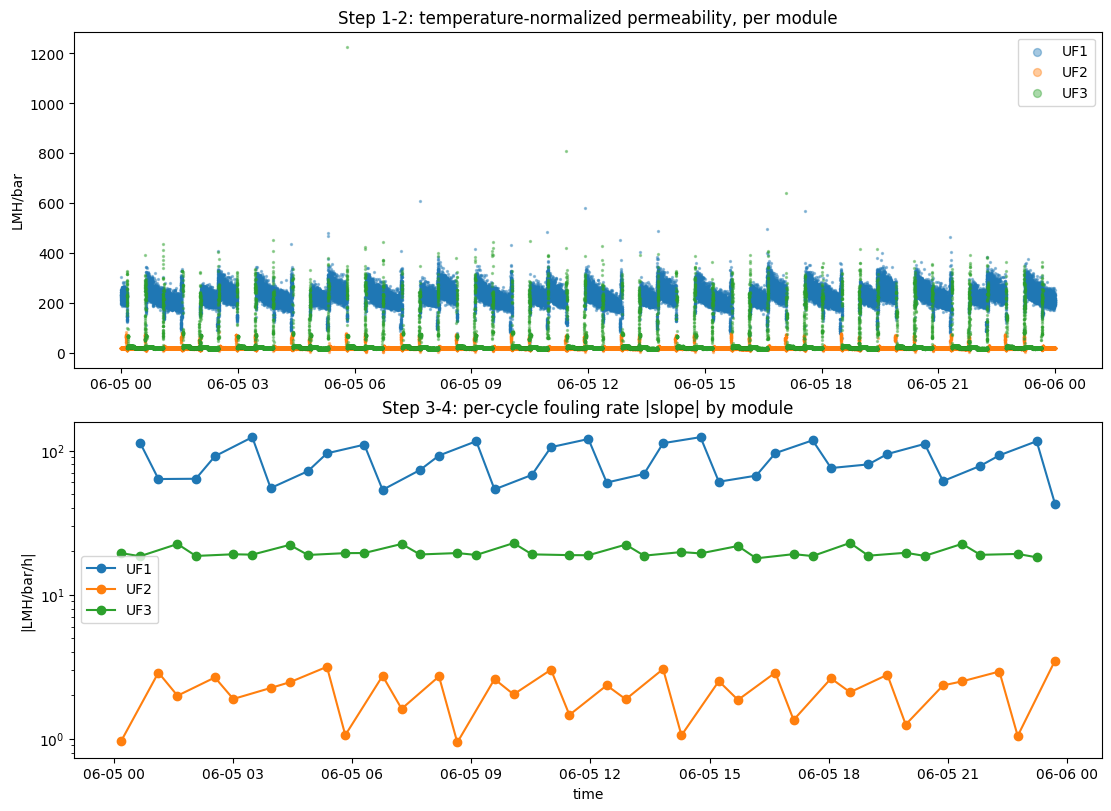

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
colors = {label: f"C{i}" for i, label in enumerate(ops)}

# (1) normalized permeability over time, one color per module
for label, op in ops.items():
    ax[0].scatter(op["time"].to_numpy(), op["norm_perm_lmh_bar"].to_numpy(),
                  s=2, color=colors[label], alpha=0.4, label=label)
ax[0].set_title("Step 1-2: temperature-normalized permeability, per module")
ax[0].set_ylabel("LMH/bar")
ax[0].legend(markerscale=4)

# (2) per-cycle fouling-rate magnitude by module
for label, cy in cycles_by_unit.items():
    ax[1].plot(cy["start"].to_numpy(), cy["fouling_rate"].abs().to_numpy(),
               "o-", color=colors[label], label=label)
ax[1].set_yscale("log")
ax[1].set_title("Step 3-4: per-cycle fouling rate |slope| by module")
ax[1].set_ylabel("|LMH/bar/h|")
ax[1].set_xlabel("time")
ax[1].legend()
plt.show()

## Notes & caveats

- **Nothing above names a raw point.** Every signal is a short facet chain that picks a point by *what
  it means* — its quantity kind plus the role of the connection point it hangs off (or the process its
  line performs, for backwash). The modules come from `instances(...)`; units come from `qudt:hasUnit`
  via `unit_of(...)` and conversions from acquirium. No `UF1`/`feed-manifold` URIs, no SCADA tag names.
- **The whole pipeline is small functions mapped over the modules** — `assemble_unit` → `normalize` →
  `assign_cycles` → `fouling_rates`/`flag_latest` — so adding or dropping a module is just a different
  `instances(...)` result, nothing to rewire.
- The absolute fouling numbers are **illustrative** for this pilot dataset; the point of the notebook is the
  acquirium workflow (discover by meaning → convert via QUDT → map one function over every module).